# Critique de l'analyse du risque de défaillance des joints toriques de la navette Challenger

## 1. Return to the original dataset

In the initial analysis, experiments with no malfunction were removed because they want to investigate only the reasons that lead to malfunction, however this data is very important.



An experiment with zero malfunction is still informative: it tells us that, under those experimental conditions, all six tested O-rings worked correctly.

Therefore, I will keep the complete dataset for the rest of the analysis.


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("module2_exo5_shuttle.csv")

data["Frequency"] = data["Malfunction"] / data["Count"]

data

,Date,Count,Temperature,Pressure,Malfunction,Frequency
0,4/12/81,6,66,50,0,0.000000
1,11/12/81,6,70,50,1,0.166667
2,3/22/82,6,69,50,0,0.000000
3,11/11/82,6,68,50,0,0.000000
4,4/04/83,6,67,50,0,0.000000
5,6/18/82,6,72,50,0,0.000000
6,8/30/83,6,73,100,0,0.000000
7,11/28/83,6,70,100,0,0.000000
8,2/03/84,6,57,200,1,0.166667
9,4/06/84,6,63,200,1,0.166667


## 2.  The pressure variable

The initial analysis assumes that the probability of malfunction depends only on temperature and remove the pressure variable because it is in most cases equal to 200.

Before accepting this assumption, I want to see whether pressure could also be related to the number of malfunctions.


In [9]:
pressure_summary = data.groupby("Pressure").agg(
    joints=("Count", "sum"),
    malfunctions=("Malfunction", "sum")
)



pressure_summary

,joints,malfunctions
Pressure,,
50,36,1
100,12,0
200,90,8


The pressure is not constant: the experiments were performed at 50, 100 and 200 psi.

Most malfunctions occurred at 200 psi, so pressure may also be relevant.


## 3. Temparature and pressure relationship

In [10]:
data.groupby("Pressure")["Temperature"].agg(
    ["min", "max", "mean"]
)

,min,max,mean
Pressure,,,
50,66,72,68.666667
100,70,73,71.500000
200,53,81,69.666667


The temperature ranges are different for different pressure levels.

In particular, the lowest temperatures were only tested at 200 psi.

Therefore, temperature and pressure cannot be considered independently in this dataset.


## 4. Fixing the presure at 200 psi
I will keep thr results for the pressure 200 psi to isolate the effect of temperature.

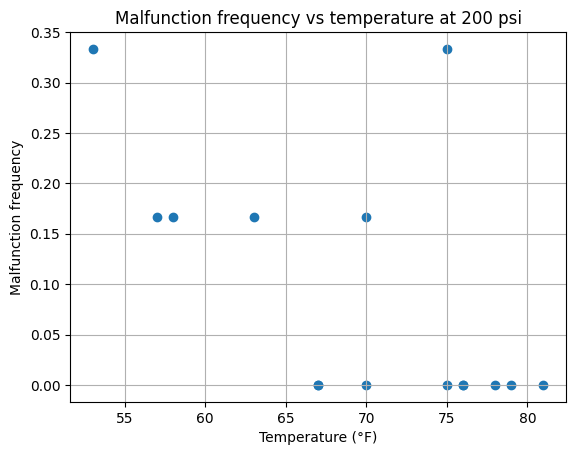

In [15]:
data_200 = data[data["Pressure"] == 200]

plt.scatter(
    data_200["Temperature"],
    data_200["Frequency"]
)

plt.xlabel("Temperature (°F)")
plt.ylabel("Malfunction frequency")
plt.title("Malfunction frequency vs temperature at 200 psi")
plt.grid(True)
plt.show()

At 200 psi, lower temperatures are associated with several malfunctions, while many of the higher-temperature experiments have no malfunction.

This suggests that temperature may affect the probability of malfunction when pressure is kept constant.
